## Le perceptrong

In [1]:
# Importation des librairies necessaires
import numpy as np
from sklearn.datasets import make_blobs
from matplotlib import pyplot as plt

Pour implémenter de bout en bout notre modèle du perceptron, nous allons générer un dataset contenant n = 50 enregistrements possédant chacun m = 2 caractéristiques avec une étiquette binaire y ∈ {0, 1}.

In [2]:
# Generation d'un dataset fictif
X, y = make_blobs(n_samples=50, n_features=2, centers=2, random_state=0)

# Creation du vecteur unitaire pour le biais
unit_vector = np.ones(X.shape[0], int)
unit_vector = unit_vector.reshape((unit_vector.shape[0], 1))

# Reformatage de la matrice des features et du vecteur target
X = np.concatenate((X, unit_vector), axis=1)
y = y.reshape((y.shape[0], 1))

Le dataset a été généré grâce à la fonction make_blobs() du package sklearn. Dans la suivante, nous représentons les données générées sur un nuage de points habillés selon les classes de la variable à prédire. Il en ressort que les deux classes sont linéairement sépérables, ce qui est compatible avec le modèle du perceptron développé dans la sous-section

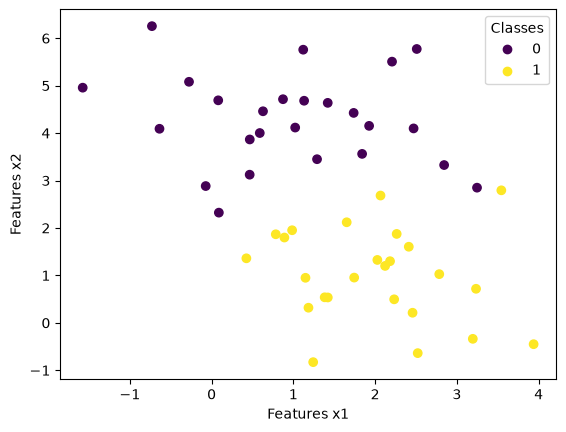

In [3]:
scatter_plot = plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel('Features x1')
plt.ylabel('Features x2')
plt.legend(* scatter_plot.legend_elements(), loc='best', title='Classes')

Pour programmer le modèle du perceptron, le code Python sera structuré comme suit :

— Initialisation des paramètres comme point de départ de l’algorithme de la descente du gradient.

— Codage des équations fondamentales du modèle.

— Évaluation du coût obtenu au niveau de l’itération en cours.

— Mise à jour des paramètres si la variation du coût à l’itération en cours n’est pas nulle.

— Répétition en boucle des deux dernières étapes jusqu’à minimiser la fonction-coût.

### Définition de la fonction d’initialisation
Elle permettra de fixer aléatoirement les paramètres initiaux de l’algorithme d’optimisation.

In [4]:
# Fonction d'initialisation
def initialize(X):
    np.random.seed(6)
    W = np.random.randn(X.shape[1], 1)
    return W

### Définition des fonctions d'agrégation et d'activation
Elles permettront de retourner la probabilité qu’un enregistrement appartienne à la classe de référence de la variable cible

In [5]:
# Equations fondamentales
def model(X, W):
    Z = X.dot(W)
    A = 1 / (1 + np.exp(-Z))
    return A

### Définition de la fonction-coût
Elle permettra de calculer l'ecart moyen entre les probabilités predites et les vraies valeurs de la variable cible.

In [6]:
# Fonction-cout
def log_loss(A, y):
    L= -1/len(y) * np.sum((y * np.log(A)) + ((1-y) * np.log(1-A)))
    return L

### Définition du vecteur Jacobien
Il permettra de mesurer la variation de la fonction-coût par rapport aux parametres obtenus dans une iteration donnée.

In [7]:
# Vecteur des gradients Jacobien
def gradients(A, X, y):
    J = 1/len(y) * np.dot(X.T, (A - y))
    return J

### Définition de la fonction de mise a jour
Elle permettra de rafraichir les parametres du modèle de sorte à minimiser les erreurs de prédiction

In [8]:
# Actualisation des parametres
def update(J, W, learning_rate):
    W = W - learning_rate * J
    return W

Après avoir codé toutes les équations, procédons à présent au codage de l’algorithme d’optimisation. 
Ce code permettra de visualiser l’évolution de la valeur du coût à travers les itérations, et de retourner les valeurs optimales des paramètres du modèle. Le taux d’apprentissage dans l’équation du gradient est fixé à α = 0.1 et le nombre d’itérations à H = 100.

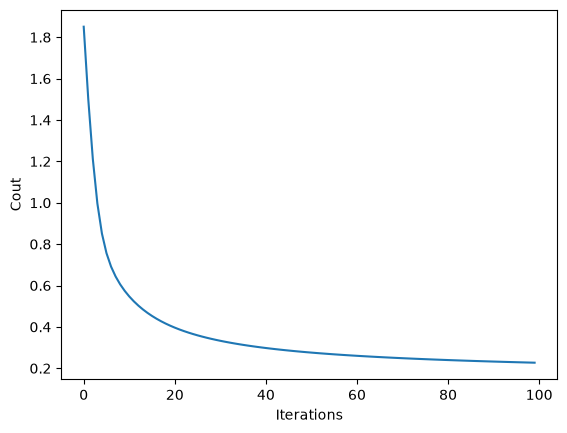

w1: 1.0164185659842155
w2: -1.0704961794165886
b : 0.8128297688531373


In [9]:
# Algorithme d’optimisation
def perceptron(X, y, learning_rate, n_iterations):
    W = initialize(X)
    L = []
    
    for h in range(n_iterations):
        A = model(X, W)
        L.append(log_loss(A, y)) 
        J = gradients(A, X, y)
        W = update(J, W, learning_rate)
        
    plt.plot(L) 
    plt.xlabel('Iterations') 
    plt.ylabel('Cout') 
    plt.show()

    return W

# Entrainement du modele
W = perceptron(X, y, learning_rate = .1, n_iterations = 100) 
print("w1:", W[0][0])
print("w2:", W[1][0])
print("b :", W[2][0])

La Figure ci-haut indique l’évolution des erreurs effectués par le modèle dans son apprentissage à partir des données. Les valeurs w1,w2 et b reprennent les valeurs optimales des paramètres du modèle de perceptron. 

Maintenant que le modèle est entraîné, il peut servir à des fins de prédiction. 
Pour cela, nous allons définir une fonction qui permettra de prédire la classe d’appartenance des enregistrements sur base de la régle définie de la sortie du perceptron. Ensuite, nous calculerons la performance du modèle, i.e. sa capacité à prédire fidèlement la classe d’appartenance d’un enregistrement étiquetté.

In [10]:
# Fonction de prediction
def predict(X, W):
    A = model(X, W)
    y_pred = []
    for i in range(X.shape[0]):
        if A[i] >= .5:
            y_pred.append(1)
        else:
            y_pred.append(0)
    return y_pred

y_pred = predict(X, W)

En Machine Learning, la performance d’un modèle est couramment évaluée au moyen d’un indicateur appelé “accuracy”. L’accuracy est une métrique simple et intuitive à comprendre qui est souvent utilisée par défaut pour évaluer les modèles de classification. 
Elle mesure la proportion de prédictions correctes par rapport au nombre total de prédictions. 
Pour la calculer, on part d’un tableau appelé “matrice de confusion”.

La matrice de confusion est un tableau à double entrée qui compare les classes réelles et les classes prédites par un modèle d’apprentissage supervisé. Chaque ligne correspond à une classe prédite et chaque colonne à une classe réelle. Une cellule donnée contient le nombre d’enregistrements de la classe réelle qui ont été classés dans la classe prédite.

In [11]:
# Matrice de confusion
def confusion_matrix(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    n_classes = np.unique(y_true).shape[0]
    confusion_matrix = np.zeros((n_classes, n_classes))
    
    for i in range(len(y_true)):
        confusion_matrix[y_true[i], y_pred[i]] += 1
        
    return confusion_matrix

# Générer la matrice de confusion brute (Scikit-Learn)
# y_true: les vraies étiquettes, y_pred: les prédictions du modèle
cm = confusion_matrix(y_true = y, y_pred = y_pred)
print(cm)

[[23.  2.]
 [ 4. 21.]]


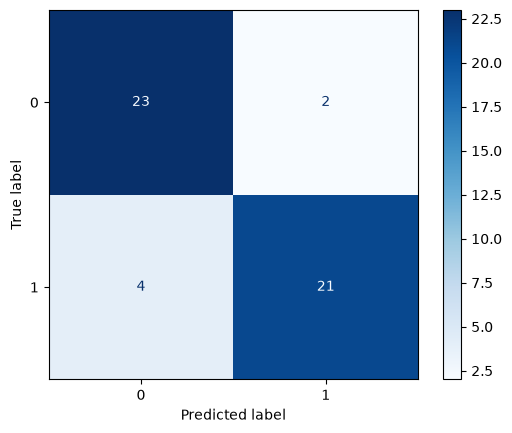

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y, y_pred, cmap="Blues")
plt.show()

À partir de la matrice de confusion, l’on peut évaluer la performance du modèle au moyen de la formule ci-dessous. Cette métrique mesure le pourcentage de prédictions correctes effectuées par le modèle.
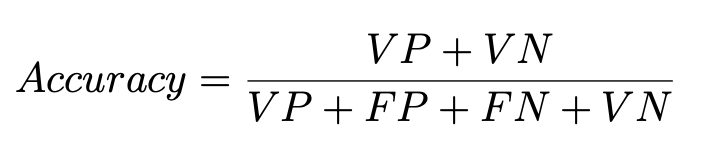

In [14]:
# Accuracy
def accuracy(confusion_matrix):
    diag = np.diag(confusion_matrix, k = 0)
    n_correct = diag.sum()
    n_total = confusion_matrix.sum()
    accuracy = n_correct / n_total
    return accuracy
Acc = accuracy(cm)
print(Acc)

0.88


Pour le cas de notre perceptron, les résultats sont présentés dans le ci-dessous. Il en ressort que quatre enregistrements n’appartenant pas à la classe de référence ont été prédits comme appartenant à cette classe, et que deux enregistrements appartenant à cette classe ont été prédits comme n’y appartenant pas. La performance globale du modèle du perceptron s’évalue ainsi à 88%.
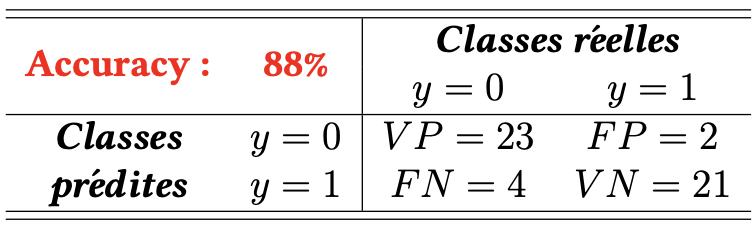

Pour clôturer cette partie, nous représentons à nouveau les données générées pour l’analyse (l’espace des features) en y traçant la frontière de décision d’équation z(wj,b) = 0. À la lumière de la figure suivante, l’on constate que les deux classes de la variable cible ont été linéairement séparées grâce la droite z(wj,b) = 0. Aussi, l’on arrive à identifier visuellement les six enregistrements qui n’ont pas été correctement prédits par le modèle.

Text(-1.5, 2, 'Frontiere \nde decision')

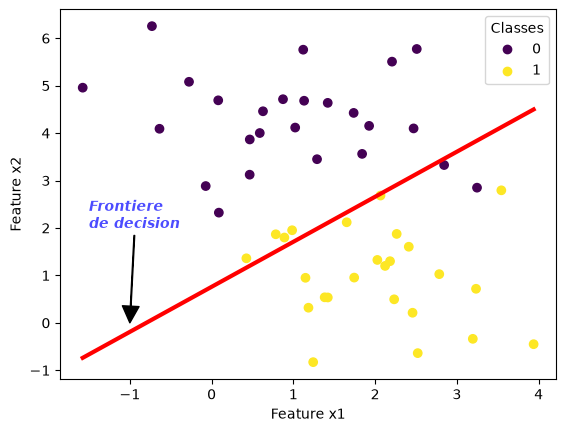

In [29]:
# Fontiere de decision
scatter_plot = plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel('Feature x1')
plt.ylabel('Feature x2')
plt.legend(*scatter_plot.legend_elements(), 
           loc='best', 
           title='Classes')

x_line = np.linspace(min(X[:, 0]), max(X[:, 0]), num = 100)
y_line = -1/W[1] * (W[0] * x_line + W[2])
plt.plot(x_line, y_line, c= 'red', lw = 3)

plt.annotate('Frontiere \nde decision', 
             (-1,0), xytext = (-1.5,2), 
             arrowprops = dict(facecolor = 'black', width = .5), 
             fontstyle = 'oblique', 
             weight = 'bold', 
             fontsize = 10, 
             color = 'blue', 
             alpha = .7)